# CATSA Model Performance Comparison

아래 표는 각 모델 노트북의 테스트 결과에서 추출한 Accuracy와 Macro F1입니다.
- 4-class: 원본 라벨 기준
- merged 3-class: 일부 라벨 병합 기준
- CNN-TF는 노트북 출력상 classification report의 macro avg F1을 사용

In [2]:
import pandas as pd

rows = [
    {"Model": "CNN",   "Setting": "4-class",        "Accuracy": 0.31, "Macro_F1": 0.199},
    {"Model": "CNN",   "Setting": "merged 3-class", "Accuracy": 0.31, "Macro_F1": 0.254},
    {"Model": "TF",    "Setting": "4-class",        "Accuracy": 0.40, "Macro_F1": 0.302},
    {"Model": "TF",    "Setting": "merged 3-class", "Accuracy": 0.43, "Macro_F1": 0.410},
    {"Model": "LSTM",  "Setting": "4-class",        "Accuracy": 0.44, "Macro_F1": 0.388},
    {"Model": "LSTM",  "Setting": "merged 3-class", "Accuracy": 0.50, "Macro_F1": 0.489},
    {"Model": "GRU",   "Setting": "4-class",        "Accuracy": 0.45, "Macro_F1": 0.388},
    {"Model": "GRU",   "Setting": "merged 3-class", "Accuracy": 0.51, "Macro_F1": 0.505},
    {"Model": "CNN-TF","Setting": "report (n=96)",  "Accuracy": 0.36, "Macro_F1": 0.360},
]

result_df = pd.DataFrame(rows)
result_df["Accuracy(%)"] = (result_df["Accuracy"] * 100).round(1)
result_df["Macro_F1"] = result_df["Macro_F1"].round(3)

result_df = result_df[["Model", "Setting", "Accuracy", "Macro_F1", "Accuracy(%)"]].sort_values(["Setting", "Accuracy"], ascending=[True, False]).reset_index(drop=True)
result_df

,Model,Setting,Accuracy,Macro_F1,Accuracy(%)
0,GRU,4-class,0.45,0.388,45.0
1,LSTM,4-class,0.44,0.388,44.0
2,TF,4-class,0.40,0.302,40.0
3,CNN,4-class,0.31,0.199,31.0
4,GRU,merged 3-class,0.51,0.505,51.0
5,LSTM,merged 3-class,0.50,0.489,50.0
6,TF,merged 3-class,0.43,0.410,43.0
7,CNN,merged 3-class,0.31,0.254,31.0
8,CNN-TF,report (n=96),0.36,0.360,36.0


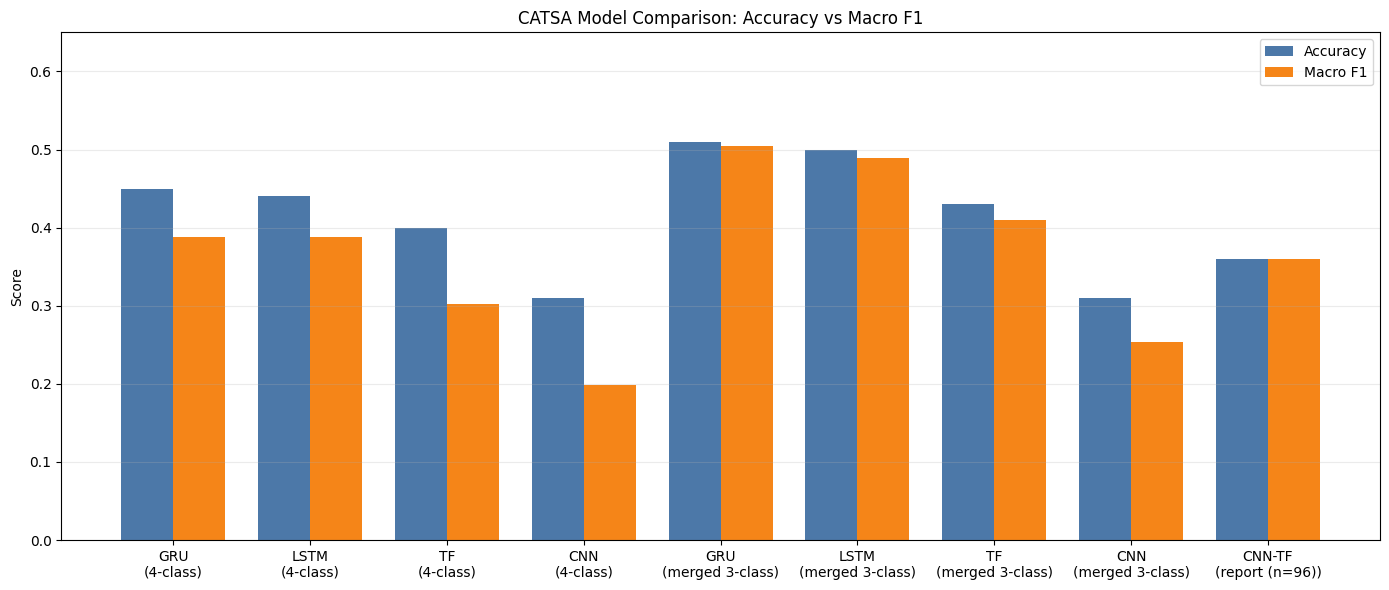

In [3]:
import matplotlib.pyplot as plt

plot_df = result_df.copy()
plot_df["Model_Setting"] = plot_df["Model"] + "\n(" + plot_df["Setting"] + ")"
plot_df = plot_df.sort_values(["Setting", "Accuracy"], ascending=[True, False]).reset_index(drop=True)

x = range(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([i - width/2 for i in x], plot_df["Accuracy"], width=width, label="Accuracy", color="#4C78A8")
ax.bar([i + width/2 for i in x], plot_df["Macro_F1"], width=width, label="Macro F1", color="#F58518")

ax.set_xticks(list(x))
ax.set_xticklabels(plot_df["Model_Setting"], rotation=0)
ax.set_ylim(0, 0.65)
ax.set_ylabel("Score")
ax.set_title("CATSA Model Comparison: Accuracy vs Macro F1")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()
